In [1]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import visualkeras

from PIL import ImageFont
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.layers import Conv2D, ReLU, MaxPooling2D, Dropout, Dense, GlobalAveragePooling2D
from sklearn.utils.class_weight import compute_class_weight
from collections import defaultdict

# Directory paths
TRAIN_DIR       = './Train'
TEST_DIR        = './Test'
LABELS_PATH     = './label_train.csv'
RESULTS_DIR     = './Results'
EXPORT_DIR      = './Export'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(EXPORT_DIR, exist_ok=True)


In [2]:
# Load training samples and corresponding labels from disk
def load_labeled_data(data_dir, csv_path):
    label_df = pd.read_csv(csv_path)
    file_paths = [os.path.join(data_dir, f"{ID}.npy") for ID in label_df['ID']]
    samples = list(map(np.load, file_paths))
    labels = label_df['target'].values
    return np.array(samples), labels

# Normalize dataset using mean and standard deviation
def normalize(data_array):
    return (data_array - np.mean(data_array)) / np.std(data_array)

# Load and preprocess the training data
features_raw, labels_raw = load_labeled_data(TRAIN_DIR, LABELS_PATH)
features_raw = normalize(features_raw)

# Split the data into training and validation sets (with class stratification)
train_data, val_data, train_labels, val_labels = train_test_split(
    features_raw, labels_raw, test_size=0.2, stratify=labels_raw, random_state=42
)


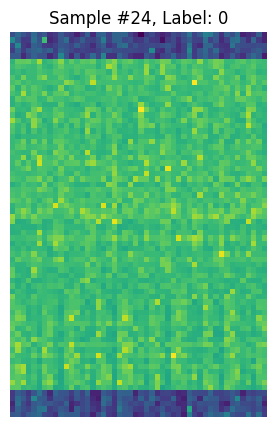

In [3]:
# Select a random training image and save it as a PDF file
def save_sample_image(data, labels, target_dir):
    existing = [f for f in os.listdir(target_dir) if re.match(r'Map_(\d+)\.pdf', f)]
    next_id = max([int(re.search(r'\d+', f).group()) for f in existing], default=0) + 1
    output_path = os.path.join(target_dir, f"Map_{next_id}.pdf")

    rand_idx = np.random.randint(len(data))
    plt.figure(figsize=(5, 5))
    plt.imshow(data[rand_idx].reshape(72, 48))
    plt.title(f"Sample #{rand_idx}, Label: {labels[rand_idx]}")
    plt.axis('off')
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    plt.show()
    plt.close()

save_sample_image(train_data, train_labels, EXPORT_DIR)


In [4]:
# Define the convolutional neural network architecture
def build_cnn():
    model = keras.Sequential([
        layers.Input(shape=(72, 48, 1)),
        layers.Conv2D(32, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(), layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(), layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(), layers.MaxPooling2D(2),
        layers.Conv2D(256, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(), layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(3, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Calculate class weights to address class imbalance
weights_array = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
weights_dict = dict(enumerate(weights_array))

# Build and train the model
cnn_model = build_cnn()
cnn_model.summary()

# Generate image of model
color_map = defaultdict(dict)
color_map[Conv2D]['fill'] = 'gray'
color_map[ReLU]['fill'] = 'green'
color_map[MaxPooling2D]['fill'] = 'blue'
color_map[Dropout]['fill'] = 'cyan'
color_map[Dense]['fill'] = 'yellow'
color_map[GlobalAveragePooling2D]['fill'] = 'purple'

existing_files = [f for f in os.listdir(EXPORT_DIR) if re.match(r'Model_(\d+)\.png', f)]
if existing_files:
    max_index = max(int(re.search(r'(\d+)', f).group()) for f in existing_files)
else:
    max_index = 0
new_index = max_index + 1
output_path = os.path.join(EXPORT_DIR, f'Model_{new_index}.png')
font_type = ImageFont.truetype("arial.ttf", 24)
visualkeras.layered_view(cnn_model, legend=True, font=font_type, to_file=output_path, spacing=10, scale_xy=5, scale_z=0.6, color_map=color_map)

history = cnn_model.fit(
    train_data, train_labels,
    validation_data=(val_data, val_labels),
    epochs=100,
    batch_size=16,
    class_weight=weights_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    ]
)




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 72, 48, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 72, 48, 32)        128       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 72, 48, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 36, 24, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 36, 24, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 36, 24, 64)       

c:\Users\jan12\Documents\MPA-MLF-Project\venv\Lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


Epoch 1/100


75/75 [==============================] - 7s 47ms/step - loss: 0.5931 - accuracy: 0.7844 - val_loss: 1.9407 - val_accuracy: 0.0936 - lr: 1.0000e-04
Epoch 2/100
75/75 [==============================] - 3s 42ms/step - loss: 0.2789 - accuracy: 0.9606 - val_loss: 3.9093 - val_accuracy: 0.0936 - lr: 1.0000e-04
Epoch 3/100
75/75 [==============================] - 3s 41ms/step - loss: 0.1926 - accuracy: 0.9799 - val_loss: 5.7531 - val_accuracy: 0.0936 - lr: 1.0000e-04
Epoch 4/100
75/75 [==============================] - 3s 41ms/step - loss: 0.1661 - accuracy: 0.9849 - val_loss: 6.4146 - val_accuracy: 0.0936 - lr: 1.0000e-04
Epoch 5/100
75/75 [==============================] - 3s 41ms/step - loss: 0.1204 - accuracy: 0.9874 - val_loss: 5.2645 - val_accuracy: 0.0936 - lr: 2.0000e-05
Epoch 6/100
75/75 [==============================] - 3s 42ms/step - loss: 0.1008 - accuracy: 0.9916 - val_loss: 3.5565 - val_accuracy: 0.1070 - lr: 2.0000e-05
Epoch 7/100
75/75 [=========================

10/10 [==============================] - 0s 19ms/step - loss: 0.0111 - accuracy: 0.9967
Validation Accuracy: 0.9967
10/10 [==============================] - 0s 16ms/step


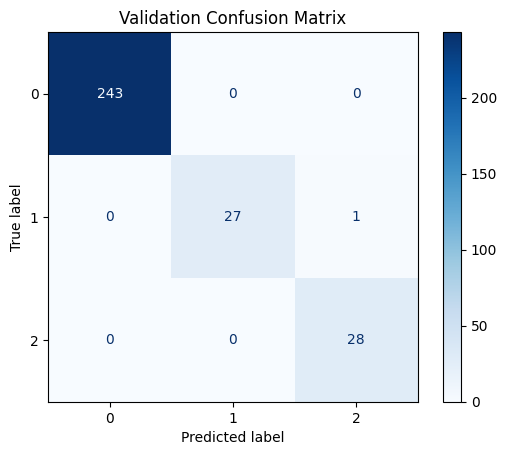

Saved confusion matrix to ./Export\Matrix_3.pdf


In [5]:
# Generate and export the confusion matrix for validation results
def save_confusion_matrix(true, predicted_probs, out_dir):
    predicted_classes = np.argmax(predicted_probs, axis=1)
    matrix = confusion_matrix(true, predicted_classes)

    existing = [f for f in os.listdir(out_dir) if re.match(r'Matrix_(\d+)\.pdf', f)]
    next_matrix = max([int(re.search(r'\d+', f).group()) for f in existing], default=0) + 1
    matrix_path = os.path.join(out_dir, f"Matrix_{next_matrix}.pdf")

    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=[0, 1, 2])
    disp.plot(cmap='Blues')
    plt.title("Validation Confusion Matrix")
    plt.savefig(matrix_path, format='pdf', bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved confusion matrix to {matrix_path}")

val_loss, val_accuracy = cnn_model.evaluate(val_data, val_labels)
print(f"Validation Accuracy: {val_accuracy:.4f}")

val_probs = cnn_model.predict(val_data)
save_confusion_matrix(val_labels, val_probs, EXPORT_DIR)


In [6]:
# Load test dataset and normalize it
def load_test_data(folder):
    file_list = sorted(
    [f for f in os.listdir(folder) if f.endswith('.npy') and f.split('.')[0].isdigit()],
    key=lambda f: int(f.split('.')[0])
    )
    data = [np.load(os.path.join(folder, f)) for f in file_list]
    data = normalize(np.array(data))
    return np.expand_dims(data, axis=-1), [f.split('.')[0] for f in file_list]

# Save predictions into CSV using next available index
def save_predictions(pred_labels, ids, result_folder):
    existing = [f for f in os.listdir(result_folder) if re.match(r'result_(\d+)\.csv', f)]
    new_index = max([int(re.search(r'\d+', f).group()) for f in existing], default=0) + 1
    output_csv = os.path.join(result_folder, f"result_{new_index}.csv")
    pd.DataFrame({'ID': ids, 'target': pred_labels}).to_csv(output_csv, index=False)
    print(f"Predictions saved to {output_csv}")
    return new_index

X_test, test_ids = load_test_data(TEST_DIR)
test_outputs = cnn_model.predict(X_test)
test_predictions = np.argmax(test_outputs, axis=1)
submission_index = save_predictions(test_predictions, test_ids, RESULTS_DIR)


4/4 [==============================] - 0s 19ms/step
Predictions saved to ./Results\result_3.csv


Training history saved at ./Export\export_3.csv


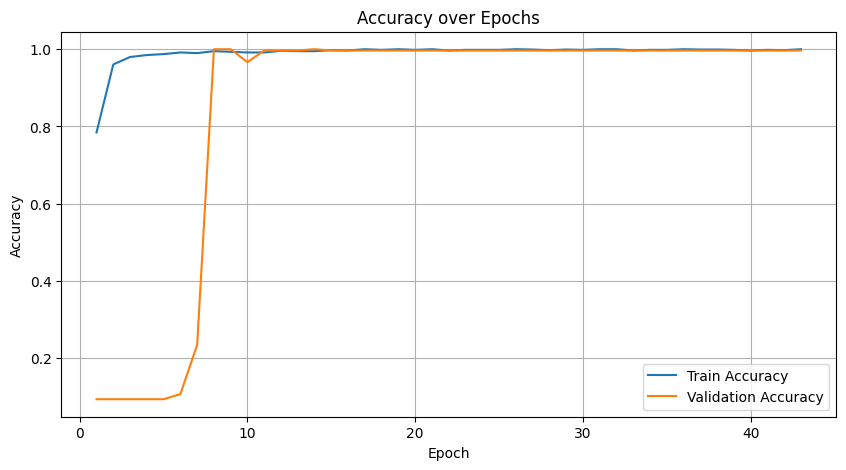

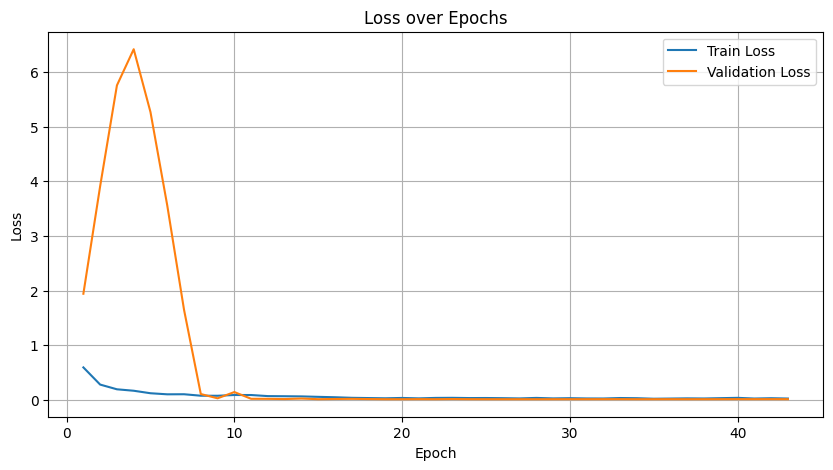

In [7]:
# Store training history as CSV
def log_training_history(hist, folder, index):
    log = {
        'epoch': list(range(1, len(hist.history['loss']) + 1)),
        'train_accuracy': hist.history['accuracy'],
        'train_loss': hist.history['loss'],
        'val_accuracy': hist.history['val_accuracy'],
        'val_loss': hist.history['val_loss']
    }
    csv_path = os.path.join(folder, f"export_{index}.csv")
    pd.DataFrame(log).to_csv(csv_path, index=False)
    print(f"Training history saved at {csv_path}")
    return log

# Plot accuracy and loss curves
def plot_training_curves(metrics_log):
    plt.figure(figsize=(10, 5))
    plt.plot(metrics_log['epoch'], metrics_log['train_accuracy'], label='Train Accuracy')
    plt.plot(metrics_log['epoch'], metrics_log['val_accuracy'], label='Validation Accuracy')
    plt.title("Accuracy over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(metrics_log['epoch'], metrics_log['train_loss'], label='Train Loss')
    plt.plot(metrics_log['epoch'], metrics_log['val_loss'], label='Validation Loss')
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

training_log = log_training_history(history, EXPORT_DIR, submission_index)
plot_training_curves(training_log)
